In [18]:
import numpy as np

input_data = np.load('initial_data/function_1/initial_inputs.npy')
print("Before:", input_data.shape)
new_point = np.array([
    [0.400690, 0.250449],
    [0.935709, 0.595154],
    ])
input_data = np.vstack([input_data, new_point])
print("After:", input_data.shape)
print(input_data)


Before: (10, 2)
After: (12, 2)
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.40069    0.250449  ]
 [0.935709   0.595154  ]]


In [20]:
output_data = np.load('initial_data/function_1/initial_outputs.npy')
print("Before:", output_data.shape)
new_output = np.array([
    1.3691278884153539e-21,
    2.0602633753627453e-67,
    ])
output_data = np.append(output_data, new_output)
print("After:", output_data.shape)
print(output_data)


Before: (10,)
After: (12,)
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.36912789e-021  2.06026338e-067]


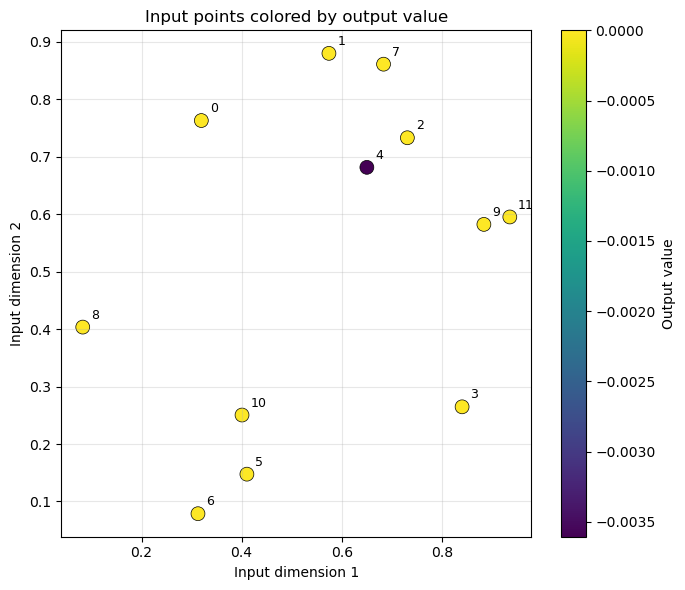

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
scatter = plt.scatter(input_data[:, 0], input_data[:, 1], 
                      c=output_data, cmap='viridis', 
                      s=100, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='Output value')

# Annotate each point with its index
for i, (x, y) in enumerate(input_data):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel('Input dimension 1')
plt.ylabel('Input dimension 2')
plt.title('Input points colored by output value')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

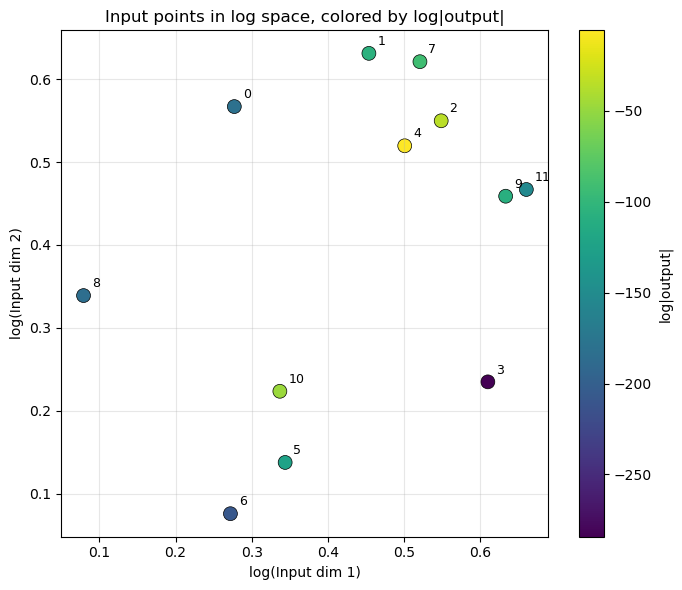

In [22]:
log_inputs = np.log1p(input_data)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(log_inputs[:, 0], log_inputs[:, 1], 
                      c=np.log(np.abs(output_data)), cmap='viridis', 
                      s=100, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='log|output|')

for i, (x, y) in enumerate(log_inputs):
    plt.annotate(str(i), (x, y), textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.xlabel('log(Input dim 1)')
plt.ylabel('log(Input dim 2)')
plt.title('Input points in log space, colored by log|output|')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

# Log-space transforms to handle extreme value ranges
X = np.log1p(input_data)          # log(1 + x),  inputs in [0, 1]
y = np.log(np.abs(output_data))   # log|y|

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

print(f"Samples : {len(X_scaled)}")
print(f"y range (scaled): [{y_scaled.min():.3f}, {y_scaled.max():.3f}]")

Samples : 12
y range (scaled): [-2.051, 1.596]


In [ ]:
import torch
import torch.nn as nn

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()         else
    torch.device("cpu")
)
print(f"Using device: {device}")


class InverseBottleneckMLP(nn.Module):
    def __init__(self, input_dim: int = 2, hidden_dim: int = 4, expansion: int = 2):
        super().__init__()
        h = hidden_dim
        self.net = nn.Sequential(
            nn.Linear(input_dim, h),
            nn.GELU(),
            nn.Linear(h, h * expansion),
            nn.GELU(),
            # nn.Linear(h * expansion, h * expansion),
            # nn.GELU(),
            nn.Linear(h * expansion, h),
            nn.GELU(),
            nn.Linear(h, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)


def train_model(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    epochs: int = 1000,
    lr: float = 3e-3,
    weight_decay: float = 1e-4,
    hidden_dim: int = 16,
    expansion: int = 4,
) -> tuple[InverseBottleneckMLP, list[float]]:       # <-- now returns (model, losses)
    model = InverseBottleneckMLP(input_dim=2, hidden_dim=hidden_dim, expansion=expansion)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()
    X_t = torch.FloatTensor(X_tr).to(device)
    y_t = torch.FloatTensor(y_tr).to(device)
    losses = []
    model.train()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        print(f"\r  epoch {epoch:4d}/{epochs}  loss={loss.item():.6f}", end="", flush=True)
    return model, losses

@torch.no_grad()
def predict(model: InverseBottleneckMLP, X: np.ndarray) -> np.ndarray:
    model.eval()
    return model(torch.FloatTensor(X).to(device)).cpu().numpy()


print(InverseBottleneckMLP())

Using device: cpu
InverseBottleneckMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=16, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=64, out_features=16, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


─────────────────────────────────────────────────────────────────
  K-Fold CV  (k=5, ~80 % train / 20 % val per fold)
─────────────────────────────────────────────────────────────────
  epoch 1000/1000  loss=0.000212
 Fold 1
   Loss curve  : e   0:0.9237  e 250:0.0001  e 500:0.0000  e 750:0.0000  e1000:0.0002
   Final loss  : 0.000212  (start: 0.923722)
                       MSE         MAE          R²
   Train            0.0000      0.0026      1.0000
   Val              0.3529      0.4046      0.7200
   Overfit ratio (val/train MSE): 31594.15
   Val predictions:
     actual=+1.5965  pred=+1.7098  Δ=-0.1133
     actual=-1.0626  pred=-0.0432  Δ=-1.0194
     actual=-0.3395  pred=-0.2584  Δ=-0.0811
  epoch 1000/1000  loss=0.000001
 Fold 2
   Loss curve  : e   0:0.9761  e 250:0.0000  e 500:0.0006  e 750:0.0000  e1000:0.0000
   Final loss  : 0.000001  (start: 0.976145)
                       MSE         MAE          R²
   Train            0.0000      0.0008      1.0000
   Val             

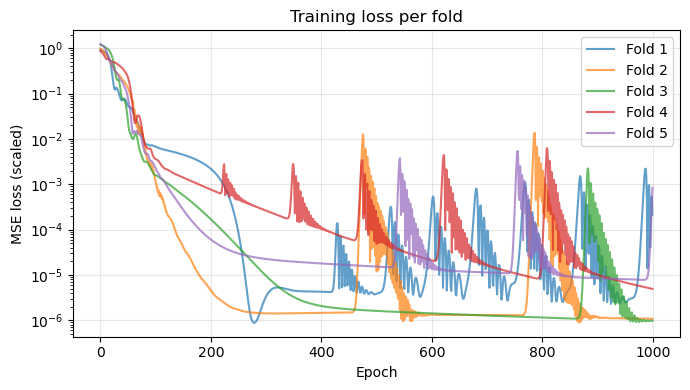

In [29]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

N_SPLITS = 5
EPOCHS   = 1000

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
cv_train_mse, cv_train_mae, cv_train_r2 = [], [], []
cv_val_mse,   cv_val_mae,   cv_val_r2   = [], [], []
cv_losses = []

print(f"{'─'*65}")
print(f"  K-Fold CV  (k={N_SPLITS}, ~80 % train / 20 % val per fold)")
print(f"{'─'*65}")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_scaled), start=1):
    X_tr,  y_tr  = X_scaled[tr_idx],  y_scaled[tr_idx]
    X_val, y_val = X_scaled[val_idx], y_scaled[val_idx]

    model, losses = train_model(X_tr, y_tr, epochs=EPOCHS)

    tr_pred  = predict(model, X_tr)
    val_pred = predict(model, X_val)

    # ── per-set metrics ───────────────────────────────────────────
    tr_mse  = np.mean((tr_pred  - y_tr)  ** 2)
    tr_mae  = np.mean(np.abs(tr_pred  - y_tr))
    tr_r2   = r2_score(y_tr,  tr_pred)

    val_mse = np.mean((val_pred - y_val) ** 2)
    val_mae = np.mean(np.abs(val_pred - y_val))
    val_r2  = r2_score(y_val, val_pred)

    cv_train_mse.append(tr_mse);  cv_val_mse.append(val_mse)
    cv_train_mae.append(tr_mae);  cv_val_mae.append(val_mae)
    cv_train_r2.append(tr_r2);    cv_val_r2.append(val_r2)
    cv_losses.append(losses)

    # ── loss curve summary ────────────────────────────────────────
    q = [0, 24, 49, 74, 99]   # epoch checkpoints at 0 % 25 % 50 % 75 % 100 %
    loss_summary = "  ".join(
        f"e{int((p/100)*EPOCHS):4d}:{losses[int((p/100)*(EPOCHS-1))]:.4f}" for p in [0, 25, 50, 75, 100]
    )

    print(f"\n Fold {fold}")
    print(f"   Loss curve  : {loss_summary}")
    print(f"   Final loss  : {losses[-1]:.6f}  (start: {losses[0]:.6f})")
    print(f"   {'':10s}   {'MSE':>10}  {'MAE':>10}  {'R²':>10}")
    print(f"   {'Train':10s}   {tr_mse:10.4f}  {tr_mae:10.4f}  {tr_r2:10.4f}")
    print(f"   {'Val':10s}   {val_mse:10.4f}  {val_mae:10.4f}  {val_r2:10.4f}")
    print(f"   Overfit ratio (val/train MSE): {val_mse/tr_mse:.2f}")
    print(f"   Val predictions:")
    for a, p in zip(y_val, val_pred):
        print(f"     actual={a:+.4f}  pred={p:+.4f}  Δ={a-p:+.4f}")

# ── aggregate summary ─────────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"  {'':10s}   {'MSE':>20}  {'MAE':>20}  {'R²':>10}")
print(f"  {'Train CV':10s}   "
      f"{np.mean(cv_train_mse):10.4f}±{np.std(cv_train_mse):.4f}  "
      f"{np.mean(cv_train_mae):10.4f}±{np.std(cv_train_mae):.4f}  "
      f"{np.mean(cv_train_r2):10.4f}")
print(f"  {'Val CV':10s}   "
      f"{np.mean(cv_val_mse):10.4f}±{np.std(cv_val_mse):.4f}  "
      f"{np.mean(cv_val_mae):10.4f}±{np.std(cv_val_mae):.4f}  "
      f"{np.mean(cv_val_r2):10.4f}")
print(f"{'─'*65}")

# ── loss curves plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for i, losses in enumerate(cv_losses, 1):
    ax.plot(losses, alpha=0.7, label=f"Fold {i}")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss (scaled)")
ax.set_title("Training loss per fold")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
print("Training final model on all data ...")
final_model, final_losses = train_model(X_scaled, y_scaled, epochs=EPOCHS)
print ()
print("Done.")

Training final model on all data ...
  epoch 1000/1000  loss=0.000144
Done.


In [27]:
query = np.array([[0.5, 0.5]])

query_scaled = scaler_X.transform(np.log1p(query))
pred_scaled  = predict(final_model, query_scaled)[0]
log_pred     = scaler_y.inverse_transform([[pred_scaled]])[0][0]

actual_output = 2.6752879910742468e-9
actual_log    = np.log(np.abs(actual_output))
pred_output   = np.exp(log_pred)
abs_error     = np.abs(pred_output - actual_output)
rel_error     = abs_error / np.abs(actual_output) * 100

print(f"Query point:           {query[0]}")
print(f"Predicted log|output|: {log_pred:.4f}")
print(f"Actual    log|output|: {actual_log:.4f}")
print(f"Predicted |output|:    {pred_output:.4e}")
print(f"Actual    |output|:    {actual_output:.4e}")
print(f"Absolute error:        {abs_error:.4e}")
print(f"Relative error:        {rel_error:.2f}%")

Query point:           [0.5 0.5]
Predicted log|output|: 13.1840
Actual    log|output|: -19.7392
Predicted |output|:    5.3176e+05
Actual    |output|:    2.6753e-09
Absolute error:        5.3176e+05
Relative error:        19876888065387592.00%
